# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Malfino Muhammad Willianz | 5054251028 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import QuantileTransformer, FunctionTransformer, StandardScaler
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.sparse.csgraph import connected_components
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)

sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('bankruptcy.csv')
df.columns = df.columns.str.strip()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Bankrupt?                                                6819 non-null   int64  
 1   ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2   ROA(A) before interest and % after tax                   6819 non-null   float64
 3   ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4   Operating Gross Margin                                   6819 non-null   float64
 5   Realized Sales Gross Margin                              6819 non-null   float64
 6   Operating Profit Rate                                    6819 non-null   float64
 7   Pre-tax net Interest Rate                                6819 non-null   float64
 8   After-tax net Interest Rate            

Dataset terdiri dari 6.819 baris dan 96 kolom (95 fitur + 1 target `Bankrupt?`), seluruhnya bertipe numerik (93 float64 dan 3 int64). Nama kolom pada file CSV asli diawali spasi (misalnya `' ROA(C) before ...'`), sehingga dilakukan `str.strip()` agar kolom lebih mudah diakses. Seluruh fitur berupa rasio keuangan perusahaan (profitabilitas, leverage/utang, arus kas, pertumbuhan, dan perputaran aset).

## Stats

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Bankrupt?,6819.0,0.032263,0.176710,0.0,0.000000,0.000000,0.000000,1.0
ROA(C) before interest and depreciation before interest,6819.0,0.505180,0.060686,0.0,0.476527,0.502706,0.535563,1.0
ROA(A) before interest and % after tax,6819.0,0.558625,0.065620,0.0,0.535543,0.559802,0.589157,1.0
ROA(B) before interest and depreciation after tax,6819.0,0.553589,0.061595,0.0,0.527277,0.552278,0.584105,1.0
Operating Gross Margin,6819.0,0.607948,0.016934,0.0,0.600445,0.605997,0.613914,1.0
...,...,...,...,...,...,...,...,...
Liability to Equity,6819.0,0.280365,0.014463,0.0,0.276944,0.278778,0.281449,1.0
Degree of Financial Leverage (DFL),6819.0,0.027541,0.015668,0.0,0.026791,0.026808,0.026913,1.0
Interest Coverage Ratio (Interest expense to EBIT),6819.0,0.565358,0.013214,0.0,0.565158,0.565252,0.565725,1.0
Net Income Flag,6819.0,1.000000,0.000000,1.0,1.000000,1.000000,1.000000,1.0


Sebagian besar fitur sudah berada pada rentang 0–1 (tampaknya sudah dinormalisasi oleh pembuat dataset), dengan nilai `std` yang sangat kecil relatif terhadap `mean`, contohnya `Operating Gross Margin` (mean ≈ 0,608, std ≈ 0,017). Kolom `Net Income Flag` memiliki `std` = 0 dan bernilai 1 di semua baris. Selain itu, terdapat beberapa kolom yang nilai maksimumnya jauh melampaui 1 (hingga orde 10⁹–10¹⁰), yang akan diperiksa lebih lanjut pada bagian EDA tambahan.

## Missing Value dan Duplikat

In [4]:
print('Total missing value:', df.isna().sum().sum())
print('Jumlah baris duplikat:', df.duplicated().sum())
print()
print('Jumlah nilai unik terkecil per kolom:')
print(df.nunique().sort_values().head(5))

Total missing value: 0


Jumlah baris duplikat: 0

Jumlah nilai unik terkecil per kolom:
Net Income Flag                      1
Bankrupt?                            2
Liability-Assets Flag                2
Total Asset Turnover               381
Net Worth Turnover Rate (times)    741
dtype: int64


Dataset tidak memiliki missing value maupun baris duplikat. Pemeriksaan jumlah nilai unik menunjukkan bahwa `Net Income Flag` hanya memiliki **1 nilai unik** (konstan), sehingga tidak membawa informasi apapun dan akan dibuang pada tahap preprocessing. `Liability-Assets Flag` merupakan satu-satunya fitur biner (selain target).

## Target

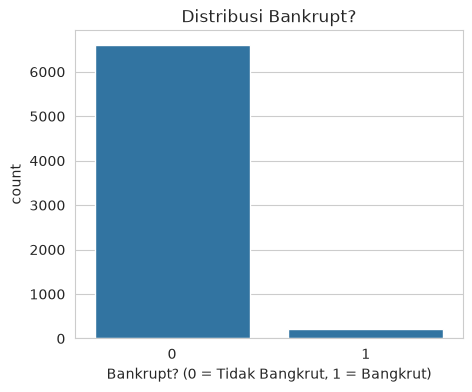

Bankrupt?
0    6599
1     220
Name: count, dtype: int64
Bankrupt?
0    96.77372
1     3.22628
Name: proportion, dtype: float64


In [5]:
plt.figure(figsize=(5, 4))
sns.countplot(x='Bankrupt?', data=df)
plt.title('Distribusi Bankrupt?')
plt.xlabel('Bankrupt? (0 = Tidak Bangkrut, 1 = Bangkrut)')
plt.show()

print(df['Bankrupt?'].value_counts())
print(df['Bankrupt?'].value_counts(normalize=True) * 100)

Distribusi target menunjukkan **ketidakseimbangan kelas yang sangat ekstrem**: 6.599 perusahaan (96,77%) tidak bangkrut dan hanya 220 perusahaan (3,23%) yang bangkrut, dengan rasio sekitar 30:1. Artinya, model "bodoh" yang selalu memprediksi "tidak bangkrut" sudah bisa mencapai akurasi ±96,8%. Oleh karena itu, **accuracy bukan metrik yang tepat** untuk dataset ini; precision, recall, dan F1-score pada kelas bangkrut (1) jauh lebih relevan untuk dipantau.

## Korelasi Antar Fitur

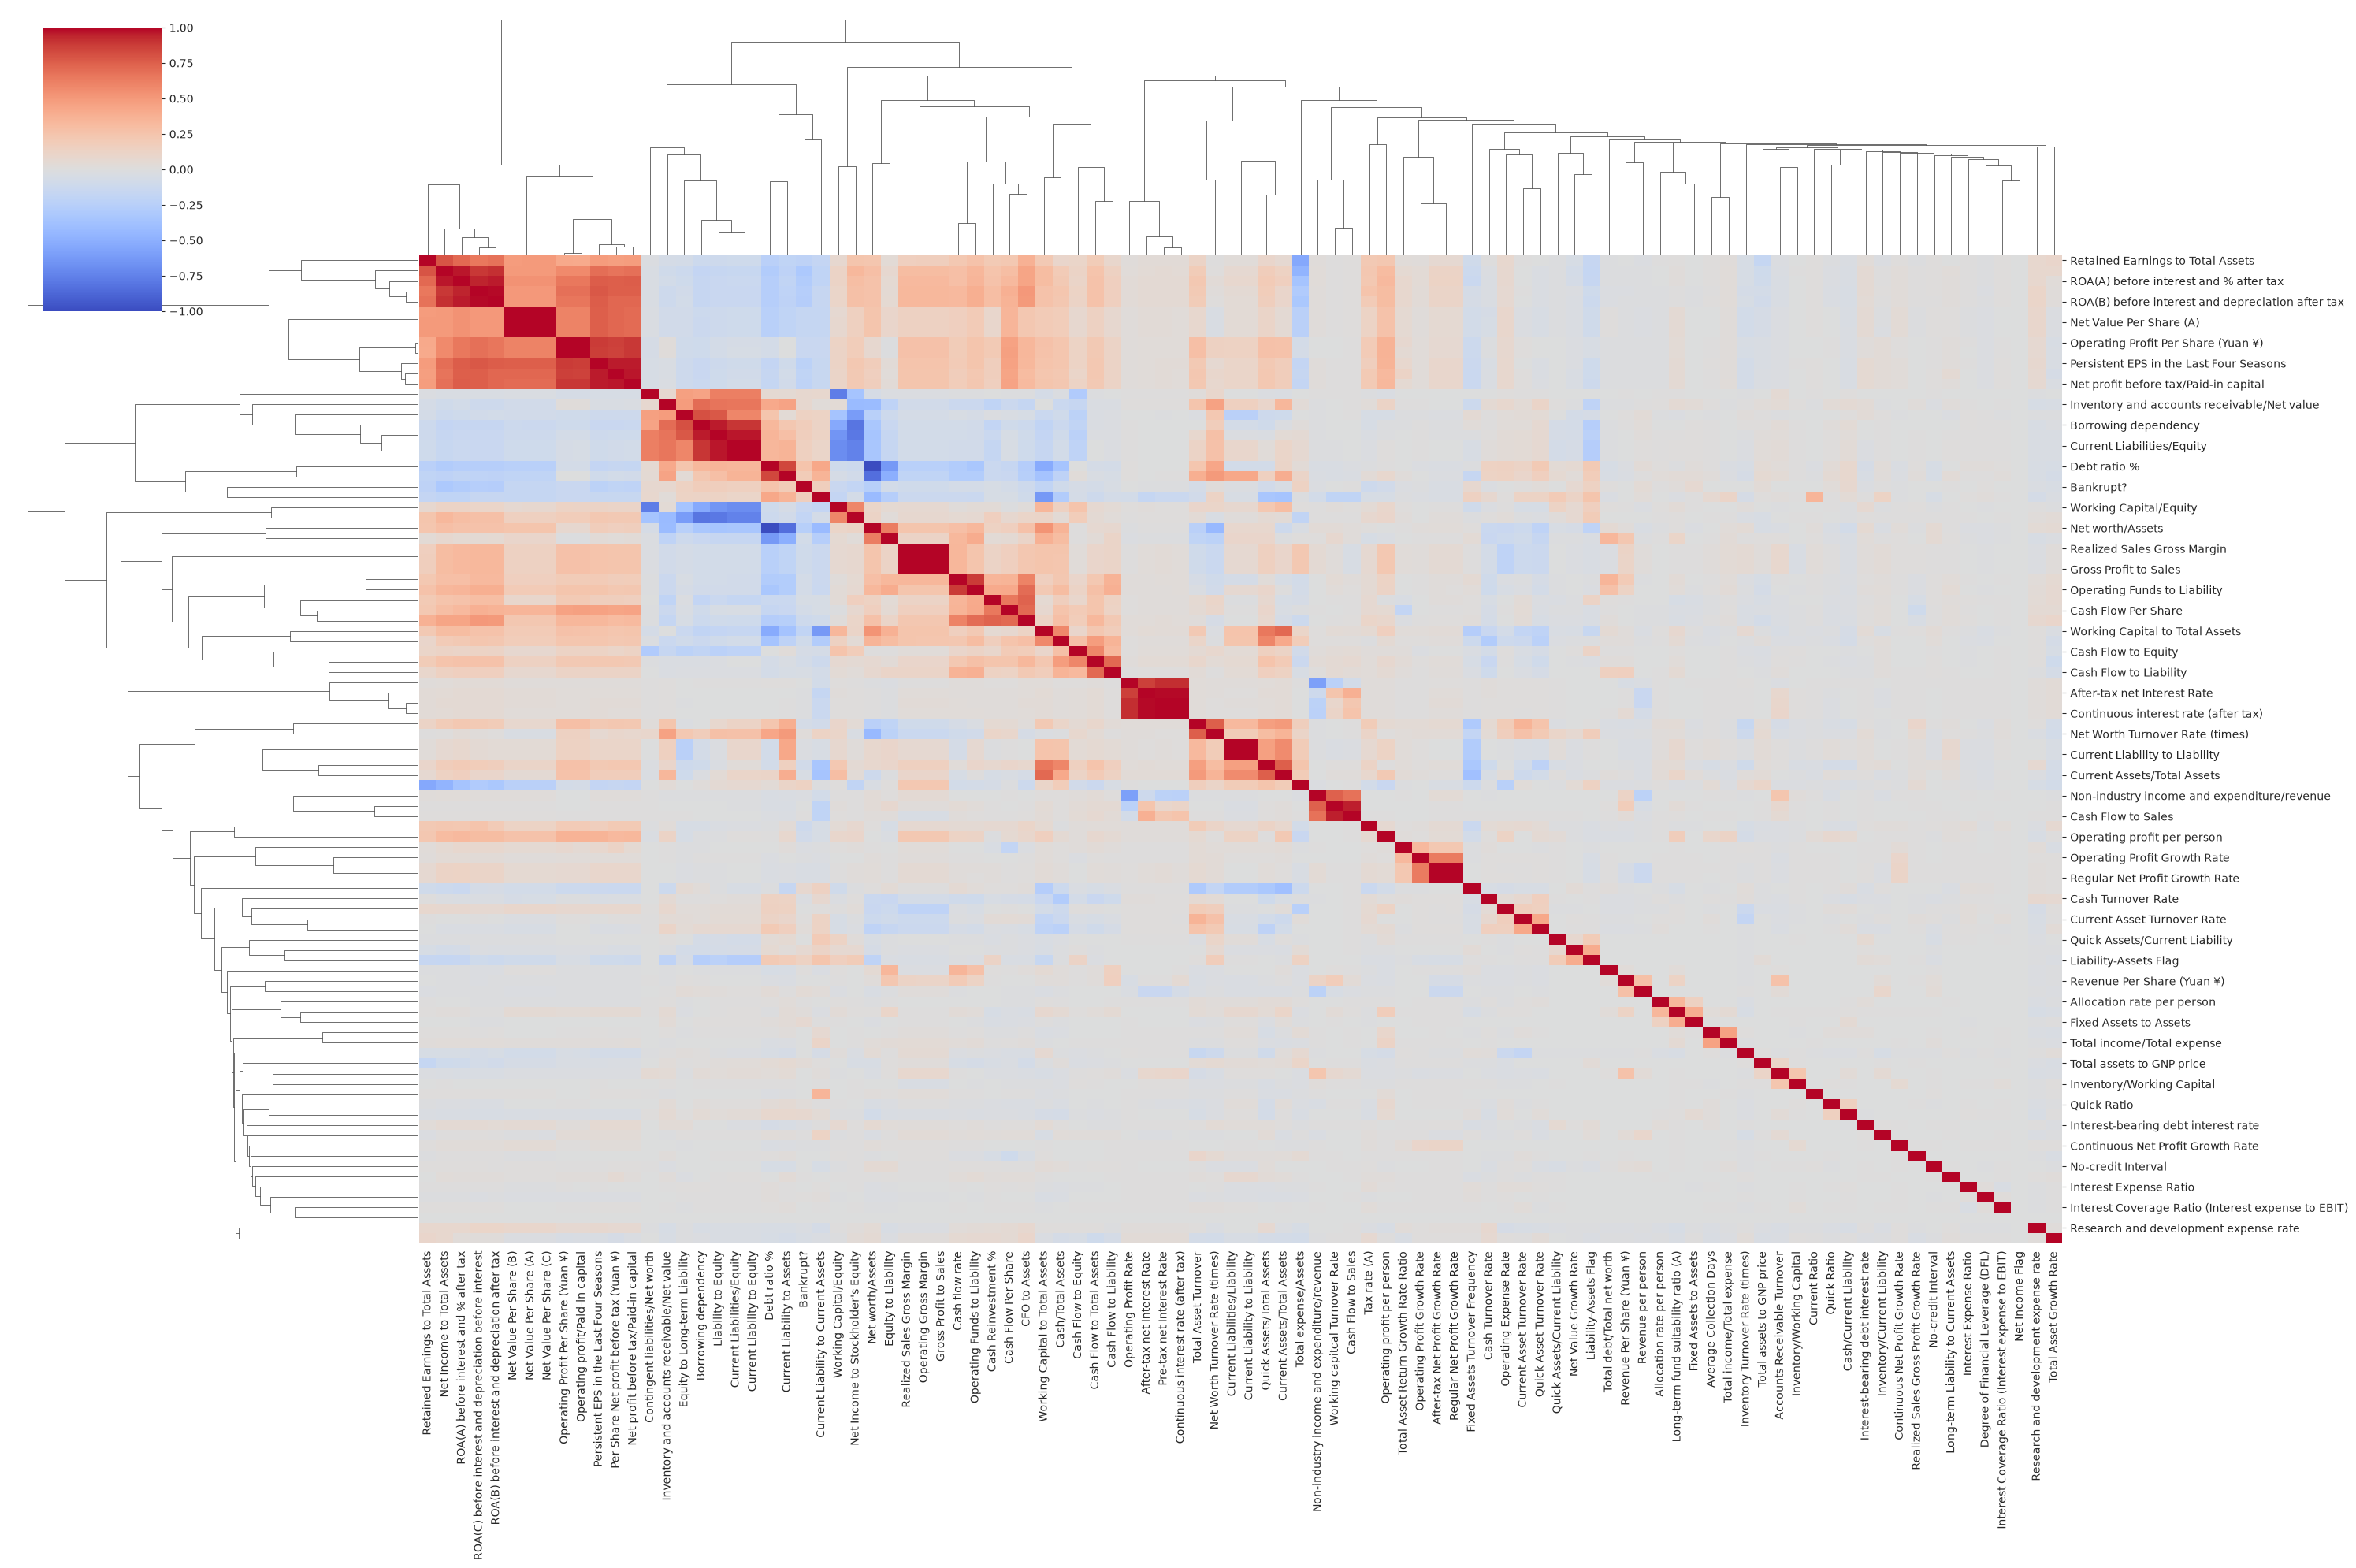

In [6]:
# Calculate correlation and remove infinite/NaN values
corr_matrix = df.corr()
corr_matrix = corr_matrix.replace([np.inf, -np.inf], np.nan)
corr_matrix = corr_matrix.fillna(0)

# Create clustermap
sns.clustermap(corr_matrix, annot=False, cmap='coolwarm', figsize=(30, 20))
plt.show()

Clustermap mengurutkan ulang fitur berdasarkan kemiripan korelasinya (hierarchical clustering), sehingga fitur-fitur yang saling berkorelasi tinggi berkumpul membentuk blok merah. Terlihat beberapa kelompok besar fitur yang redundan: kelompok **profitabilitas** (ROA A/B/C, Net Income to Total Assets, Net Value Per Share A/B/C, EPS, Operating Profit Per Share), kelompok **leverage** (Borrowing dependency, Liability to Equity, Current Liabilities/Equity), kelompok **gross margin**, dan kelompok **interest rate**. Target `Bankrupt?` sendiri berada di dekat kelompok `Debt ratio %` dan `Current Liability to Assets`, mengindikasikan bahwa fitur utang paling dekat hubungannya dengan kebangkrutan. Sekitar setengah fitur sisanya (diagonal bagian kanan bawah) hampir tidak berkorelasi dengan fitur lain.

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

### Fitur Paling Berkorelasi dengan Target

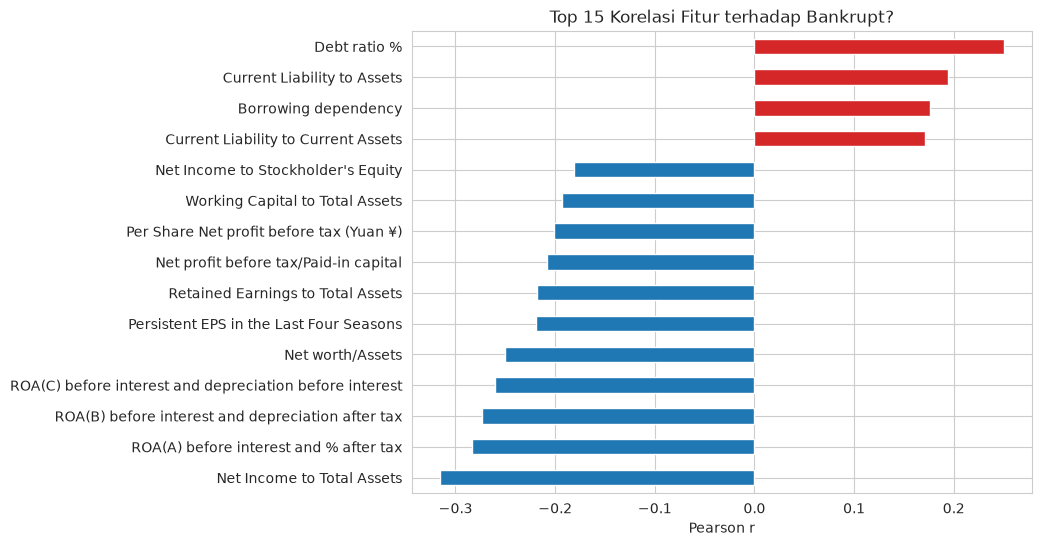

Net Income to Total Assets                                -0.315457
ROA(A) before interest and % after tax                    -0.282941
ROA(B) before interest and depreciation after tax         -0.273051
ROA(C) before interest and depreciation before interest   -0.260807
Net worth/Assets                                          -0.250161
Debt ratio %                                               0.250161
Persistent EPS in the Last Four Seasons                   -0.219560
Retained Earnings to Total Assets                         -0.217779
Net profit before tax/Paid-in capital                     -0.207857
Per Share Net profit before tax (Yuan ¥)                  -0.201395
Current Liability to Assets                                0.194494
Working Capital to Total Assets                           -0.193083
Net Income to Stockholder's Equity                        -0.180987
Borrowing dependency                                       0.176543
Current Liability to Current Assets             

In [7]:
target_corr = corr_matrix['Bankrupt?'].drop('Bankrupt?').sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 6))
target_corr.head(15).sort_values().plot.barh(color=['tab:red' if v > 0 else 'tab:blue' for v in target_corr.head(15).sort_values()])
plt.title('Top 15 Korelasi Fitur terhadap Bankrupt?')
plt.xlabel('Pearson r')
plt.show()

target_corr.head(15)

Tidak ada satu pun fitur yang berkorelasi kuat secara linear dengan `Bankrupt?`; korelasi tertinggi hanya `Net Income to Total Assets` (r ≈ -0,32), diikuti ROA(A), ROA(B), dan ROA(C) (r ≈ -0,26 s.d. -0,28). Fitur profitabilitas berkorelasi **negatif** (semakin untung, semakin kecil peluang bangkrut), sedangkan fitur utang seperti `Debt ratio %` (r ≈ 0,25), `Current Liability to Assets` (r ≈ 0,19), dan `Borrowing dependency` (r ≈ 0,18) berkorelasi **positif**. Korelasi linear yang lemah ini tidak berarti fitur tidak berguna, karena Decision Tree dapat menangkap hubungan non-linear melalui threshold.

### Pasangan Fitur Redundan

In [8]:
upper = corr_matrix.drop(index='Bankrupt?', columns='Bankrupt?')
upper = upper.where(np.triu(np.ones(upper.shape, dtype=bool), k=1)).stack()
redundant = upper[upper.abs() > 0.95].sort_values(key=abs, ascending=False)

print(f'Jumlah pasangan fitur dengan |r| > 0.95: {len(redundant)}')
redundant

Jumlah pasangan fitur dengan |r| > 0.95: 23


Current Liabilities/Liability                            Current Liability to Liability                       1.000000
Current Liabilities/Equity                               Current Liability to Equity                          1.000000
Debt ratio %                                             Net worth/Assets                                    -1.000000
Operating Gross Margin                                   Gross Profit to Sales                                1.000000
Net Value Per Share (A)                                  Net Value Per Share (C)                              0.999837
Operating Gross Margin                                   Realized Sales Gross Margin                          0.999518
Realized Sales Gross Margin                              Gross Profit to Sales                                0.999518
Net Value Per Share (B)                                  Net Value Per Share (A)                              0.999342
                                                

Terdapat 23 pasangan fitur dengan |r| > 0,95, beberapa bahkan identik (r = 1,0), misalnya `Current Liabilities/Liability` dengan `Current Liability to Liability`, `Operating Gross Margin` dengan `Gross Profit to Sales`, serta `Debt ratio %` dengan `Net worth/Assets` (r = -1,0, karena secara definisi saling komplemen). Decision Tree tidak terganggu oleh multikolinearitas dari sisi performa, sehingga fitur-fitur ini **tidak dibuang**. Namun, redundansi ini perlu diingat saat membaca feature importance: dari beberapa fitur kembar, tree hanya akan memilih salah satu secara "acak", sehingga importance fitur kembarannya bisa bernilai 0 meskipun informasinya sama penting.

### Fitur Teratas vs Target

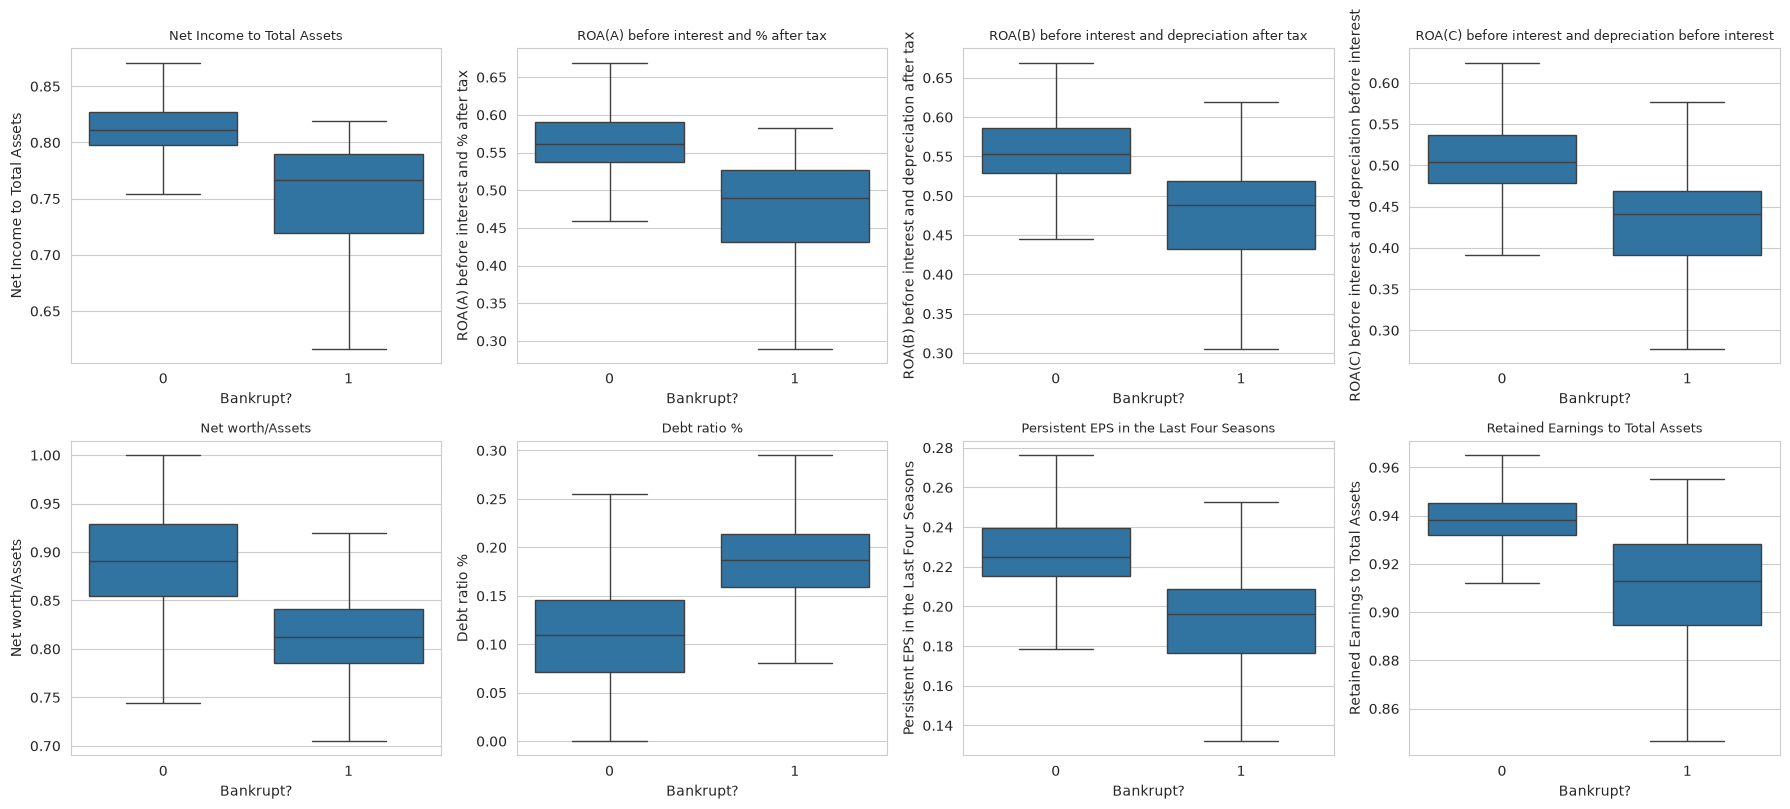

In [9]:
top_features = target_corr.head(8).index

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(top_features):
    sns.boxplot(x='Bankrupt?', y=col, data=df, ax=axes[i], showfliers=False)
    axes[i].set_title(col, fontsize=9)

plt.tight_layout()
plt.show()

Boxplot (tanpa outlier) pada 8 fitur dengan korelasi tertinggi menunjukkan pola yang konsisten: perusahaan bangkrut memiliki nilai profitabilitas (ROA, Net Income to Total Assets, EPS) yang lebih rendah, serta `Debt ratio %` yang lebih tinggi (median ≈ 0,187 vs 0,109 pada perusahaan tidak bangkrut). Meski median antar kelas bergeser, rentang kedua kelas masih cukup tumpang tindih, sehingga pemisahan kelas tidak dapat dilakukan hanya dengan satu fitur.

### Nilai Anomali (Skala Tidak Konsisten)

In [10]:
desc = df.describe().T
big_cols = desc[desc['max'] > 1].index.drop('Bankrupt?', errors='ignore')

print(f'Jumlah kolom dengan nilai > 1: {len(big_cols)}')
print()
for col in big_cols:
    n_big = (df[col] > 1).sum()
    print(f'{col}: {n_big} baris ({n_big / len(df) * 100:.2f}%), max = {df[col].max():.3g}')

Jumlah kolom dengan nilai > 1: 24

Operating Expense Rate: 2282 baris (33.47%), max = 9.99e+09
Research and development expense rate: 4033 baris (59.14%), max = 9.98e+09
Interest-bearing debt interest rate: 221 baris (3.24%), max = 9.9e+08
Revenue Per Share (Yuan ¥): 5 baris (0.07%), max = 3.02e+09
Total Asset Growth Rate: 6017 baris (88.24%), max = 9.99e+09
Net Value Growth Rate: 2 baris (0.03%), max = 9.33e+09
Current Ratio: 1 baris (0.01%), max = 2.75e+09
Quick Ratio: 9 baris (0.13%), max = 9.23e+09
Total debt/Total net worth: 8 baris (0.12%), max = 9.94e+09
Accounts Receivable Turnover: 22 baris (0.32%), max = 9.74e+09
Average Collection Days: 18 baris (0.26%), max = 9.73e+09
Inventory Turnover Rate (times): 2946 baris (43.20%), max = 9.99e+09
Fixed Assets Turnover Frequency: 1228 baris (18.01%), max = 9.99e+09
Revenue per person: 2 baris (0.03%), max = 8.81e+09
Allocation rate per person: 12 baris (0.18%), max = 9.57e+09
Quick Assets/Current Liability: 3 baris (0.04%), max = 8.82e

Terdapat 24 kolom yang mengandung nilai > 1, padahal mayoritas nilai kolom tersebut berada pada rentang 0–1. Nilai-nilai ini berada pada orde 10⁸–10¹⁰, yang jelas tidak konsisten dengan skala lainnya dan kemungkinan merupakan artefak pengolahan data (misalnya nilai rasio yang tidak dinormalisasi atau kode error). Pada beberapa kolom proporsinya kecil (<1%), namun pada `Total Asset Growth Rate` (88,24%), `Cash Turnover Rate` (62,16%), dan `Research and development expense rate` (59,14%) proporsinya justru mayoritas. Karena Decision Tree melakukan split berdasarkan threshold (hanya urutan nilai yang berpengaruh, bukan besarnya), nilai ekstrem ini **tidak mengganggu** proses split sehingga dibiarkan apa adanya tanpa clipping atau transformasi.

# 2. Preprocessing

In [11]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
print('Total missing value:', df.isna().sum().sum())

# Net Income Flag hanya memiliki satu nilai unik sehingga tidak informatif
df = df.drop(columns=['Net Income Flag'])

Total missing value: 0


In [12]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Catatan: Decision Tree secara konsep bisa menangani fitur kategorikal secara langsung tanpa One-Hot Encoding,
# tetapi implementasi DecisionTreeClassifier pada scikit-learn tetap mengharuskan input berupa angka.
print(df.select_dtypes(exclude='number').columns.tolist())
print(df['Liability-Assets Flag'].value_counts())

[]
Liability-Assets Flag
0    6811
1       8
Name: count, dtype: int64


In [13]:
X = df.drop(columns=['Bankrupt?'])
y = df['Bankrupt?']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Train shape: (5455, 94)
Test shape : (1364, 94)
Bankrupt?
0    0.967736
1    0.032264
Name: proportion, dtype: float64
Bankrupt?
0    0.967742
1    0.032258
Name: proportion, dtype: float64


Preprocessing yang dilakukan cukup sederhana karena karakteristik dataset:

| Tahap | Keputusan |
|---|---|
| Missing value | Tidak ada, sehingga tidak diperlukan imputasi |
| Fitur konstan | `Net Income Flag` dibuang karena hanya memiliki 1 nilai unik |
| Encoding | Tidak diperlukan, seluruh fitur sudah numerik (`Liability-Assets Flag` sudah berupa 0/1) |
| Outlier/nilai ekstrem | Dibiarkan, karena split Decision Tree hanya bergantung pada urutan nilai |
| Scaling | Tidak diperlukan untuk Decision Tree |

Data dibagi 80:20 menggunakan `stratify=y` sehingga proporsi kelas bangkrut tetap ±3,23% pada train (5.455 baris) maupun test (1.364 baris). Stratifikasi sangat penting di sini, karena tanpa stratifikasi jumlah sampel bangkrut di test set (hanya 44 perusahaan) bisa berfluktuasi cukup jauh.

**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

## 2.1 Eksperimen Preprocessing Tambahan

Berdasarkan EDA, dataset memiliki banyak fitur redundan (23 pasangan dengan |r| > 0,95) dan skala yang tidak konsisten. Pada bagian ini dicoba beberapa teknik reduksi dimensi/fitur untuk melihat apakah dapat membantu Decision Tree:

| Variasi | Keterangan |
|---|---|
| Tanpa reduksi | Seluruh 94 fitur digunakan apa adanya |
| Drop redundan | Membuang salah satu fitur dari setiap pasangan dengan \|r\| > 0,95 (dihitung dari train set saja) |
| GroupSVD per kelompok redundan | Setiap kelompok fitur yang saling berkorelasi \|r\| > 0,95 dikompres menjadi 1 komponen TruncatedSVD (setelah StandardScaler), fitur lain tetap asli |
| TruncatedSVD (tanpa transformasi) | SVD langsung pada data asli yang mengandung nilai ekstrem hingga 10¹⁰ |
| Quantile + TruncatedSVD / PCA | Data ditransformasi dengan `QuantileTransformer` (menghilangkan efek nilai ekstrem) lalu direduksi menjadi k komponen |

Seluruh variasi dievaluasi dengan **5-fold Stratified Cross-Validation pada train set** (Decision Tree Gini, `max_depth=5`) menggunakan metrik F1 kelas bangkrut. Seluruh transformasi dibungkus dalam `Pipeline` sehingga di-fit ulang hanya pada fold training di setiap iterasi, dan test set tidak disentuh sama sekali untuk menghindari data leakage.

Untuk variasi GroupSVD, dibuat transformer kustom `GroupSVD` yang mengelompokkan fitur redundan menggunakan connected components pada graf korelasi (dua fitur terhubung jika |r| > 0,95), lalu mengompres setiap kelompok menjadi satu komponen. Berbeda dengan SVD global, pendekatan ini hanya menggabungkan fitur yang memang mengukur hal yang sama, sehingga setiap komponen masih dapat diinterpretasikan (misalnya `group1_svd1` ≈ "ROA gabungan").

In [14]:
class GroupSVD(BaseEstimator, TransformerMixin):
    """Kompres setiap kelompok fitur redundan (|r| > threshold) menjadi komponen TruncatedSVD,
    fitur lain yang tidak redundan dibiarkan apa adanya."""

    def __init__(self, threshold=0.95, n_components=1):
        self.threshold = threshold
        self.n_components = n_components

    def fit(self, X, y=None):
        # Kelompokkan fitur yang saling terhubung dengan |r| > threshold
        corr = X.corr().abs().fillna(0).to_numpy(copy=True)
        np.fill_diagonal(corr, 0)
        _, labels = connected_components(corr > self.threshold, directed=False)
        self.groups_ = [list(X.columns[labels == g]) for g in np.unique(labels) if (labels == g).sum() > 1]

        self.models_ = []
        for cols in self.groups_:
            scaler = StandardScaler().fit(X[cols])
            svd = TruncatedSVD(n_components=min(self.n_components, len(cols) - 1), random_state=42)
            svd.fit(scaler.transform(X[cols]))
            self.models_.append((scaler, svd))
        return self

    def transform(self, X):
        grouped_cols = [col for cols in self.groups_ for col in cols]
        out = [X.drop(columns=grouped_cols)]
        for i, (cols, (scaler, svd)) in enumerate(zip(self.groups_, self.models_)):
            Z = svd.transform(scaler.transform(X[cols]))
            out.append(pd.DataFrame(Z, index=X.index, columns=[f'group{i + 1}_svd{j + 1}' for j in range(Z.shape[1])]))
        return pd.concat(out, axis=1)

In [15]:
group_svd = GroupSVD(threshold=0.95).fit(X_train)

group_info = pd.DataFrame({
    'Jumlah Fitur': [len(cols) for cols in group_svd.groups_],
    'Explained Variance (1 komponen)': [svd.explained_variance_ratio_[0] for _, svd in group_svd.models_],
    'Fitur': [', '.join(cols) for cols in group_svd.groups_],
}, index=[f'group{i + 1}' for i in range(len(group_svd.groups_))])

print(f'Jumlah fitur setelah GroupSVD: {group_svd.transform(X_train).shape[1]}')
pd.set_option('display.max_colwidth', None)
group_info

Jumlah fitur setelah GroupSVD: 74


,Jumlah Fitur,Explained Variance (1 komponen),Fitur
group1,4,0.954970,"ROA(C) before interest and depreciation before interest, ROA(A) before interest and % after tax, ROA(B) before interest and depreciation after tax, Net Income to Total Assets"
group2,3,0.999762,"Operating Gross Margin, Realized Sales Gross Margin, Gross Profit to Sales"
group3,4,0.938291,"Operating Profit Rate, Non-industry income and expenditure/revenue, Working capitcal Turnover Rate, Cash Flow to Sales"
group4,3,0.995711,"Pre-tax net Interest Rate, After-tax net Interest Rate, Continuous interest rate (after tax)"
group5,3,0.999836,"Net Value Per Share (B), Net Value Per Share (A), Net Value Per Share (C)"
group6,3,0.986110,"Persistent EPS in the Last Four Seasons, Per Share Net profit before tax (Yuan ¥), Net profit before tax/Paid-in capital"
group7,2,0.999433,"Operating Profit Per Share (Yuan ¥), Operating profit/Paid-in capital"
group8,2,0.998285,"After-tax Net Profit Growth Rate, Regular Net Profit Growth Rate"
group9,2,1.000000,"Debt ratio %, Net worth/Assets"
group10,2,1.000000,"Current Liabilities/Liability, Current Liability to Liability"


In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Fitur redundan ditentukan hanya dari train set agar tidak terjadi data leakage
train_corr = X_train.corr().abs()
train_upper = train_corr.where(np.triu(np.ones(train_corr.shape, dtype=bool), k=1))
redundant_cols = [col for col in train_upper.columns if (train_upper[col] > 0.95).any()]
print(f'Jumlah fitur redundan (|r| > 0.95) yang dibuang: {len(redundant_cols)}')

drop_redundant = FunctionTransformer(lambda Z: Z.drop(columns=redundant_cols))

prep_variants = {
    'Tanpa reduksi (94 fitur)': [],
    f'Drop redundan ({X.shape[1] - len(redundant_cols)} fitur)': [drop_redundant],
    'GroupSVD per kelompok redundan (74 fitur)': [GroupSVD(threshold=0.95)],
    'TruncatedSVD (tanpa transformasi)': [TruncatedSVD(n_components=10, random_state=42)],
}
for k in [5, 10, 20, 40]:
    prep_variants[f'Quantile + TruncatedSVD (k={k})'] = [QuantileTransformer(output_distribution='normal', random_state=42),
                                                         TruncatedSVD(n_components=k, random_state=42)]
    prep_variants[f'Quantile + PCA (k={k})'] = [QuantileTransformer(output_distribution='normal', random_state=42),
                                                PCA(n_components=k, random_state=42)]

Jumlah fitur redundan (|r| > 0.95) yang dibuang: 18


In [17]:
prep_results = []
for name, steps in prep_variants.items():
    pipe = make_pipeline(*steps, DecisionTreeClassifier(max_depth=5, random_state=42))
    cv_f1 = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1')
    prep_results.append({'Preprocessing': name, 'CV F1 (mean)': cv_f1.mean(), 'CV F1 (std)': cv_f1.std()})

prep_results = pd.DataFrame(prep_results).set_index('Preprocessing').sort_values('CV F1 (mean)', ascending=False)
prep_results

,CV F1 (mean),CV F1 (std)
Preprocessing,,
Drop redundan (76 fitur),0.330987,0.100858
GroupSVD per kelompok redundan (74 fitur),0.297160,0.046975
Tanpa reduksi (94 fitur),0.292827,0.085739
Quantile + PCA (k=20),0.280445,0.070062
Quantile + PCA (k=40),0.235277,0.047124
Quantile + PCA (k=10),0.235201,0.117418
Quantile + TruncatedSVD (k=40),0.185982,0.082650
Quantile + TruncatedSVD (k=20),0.168407,0.103523
Quantile + TruncatedSVD (k=5),0.157912,0.056304


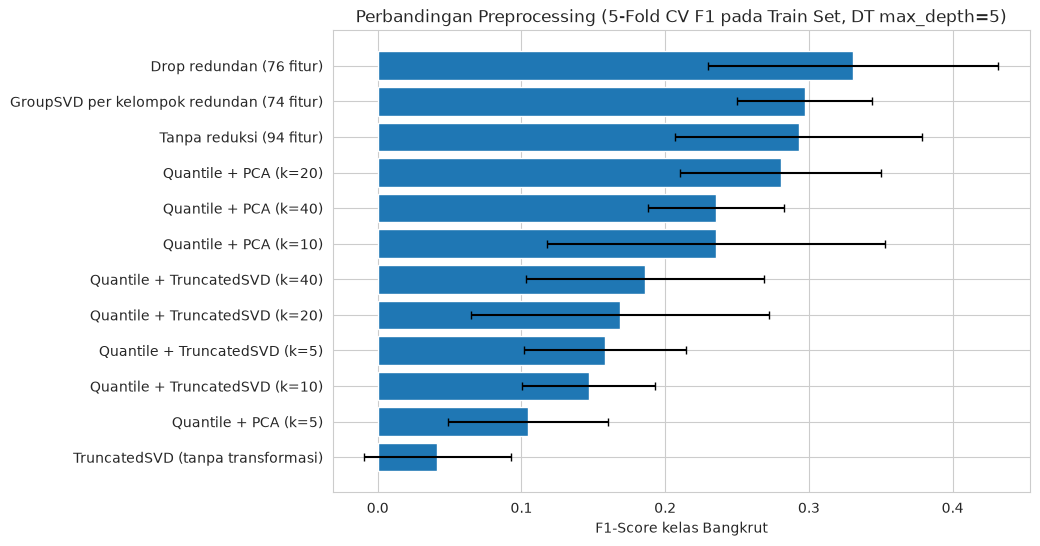

In [18]:
plt.figure(figsize=(9, 6))
plt.barh(prep_results.index[::-1], prep_results['CV F1 (mean)'][::-1],
         xerr=prep_results['CV F1 (std)'][::-1], capsize=3)
plt.title('Perbandingan Preprocessing (5-Fold CV F1 pada Train Set, DT max_depth=5)')
plt.xlabel('F1-Score kelas Bangkrut')
plt.show()

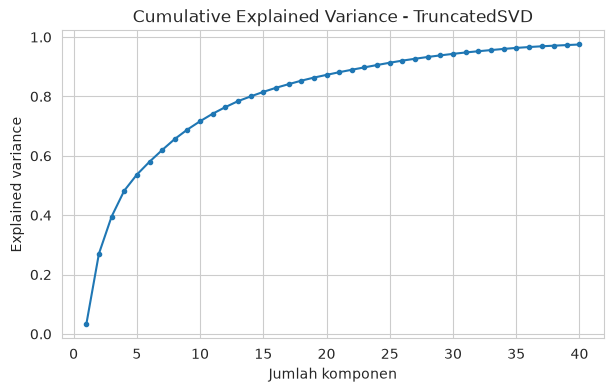

k=5: 53.7%
k=10: 71.7%
k=20: 87.3%
k=40: 97.5%


In [19]:
svd_pipe = make_pipeline(QuantileTransformer(output_distribution='normal', random_state=42),
                         TruncatedSVD(n_components=40, random_state=42))
svd_pipe.fit(X_train)
explained = np.cumsum(svd_pipe[-1].explained_variance_ratio_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, 41), explained, marker='o', markersize=3)
plt.title('Cumulative Explained Variance - TruncatedSVD')
plt.xlabel('Jumlah komponen')
plt.ylabel('Explained variance')
plt.show()

for k in [5, 10, 20, 40]:
    print(f'k={k}: {explained[k - 1] * 100:.1f}%')

Hasil eksperimen menunjukkan bahwa **reduksi dimensi dengan TruncatedSVD maupun PCA justru menurunkan performa Decision Tree** di semua nilai k. Variasi terbaik dari keluarga ini (Quantile + PCA k=20, F1 ≈ 0,280) masih di bawah model tanpa reduksi (F1 ≈ 0,293), sedangkan TruncatedSVD pada data asli tanpa transformasi hampir tidak bisa mendeteksi kelas bangkrut sama sekali (F1 ≈ 0,042), karena komponen SVD didominasi oleh segelintir kolom bernilai 10⁹–10¹⁰ dan bukan oleh pola keuangan yang bermakna. Meskipun 20 komponen SVD sudah menjelaskan 87,3% variansi, variansi yang besar tidak sama dengan informasi yang relevan untuk memisahkan kelas minoritas (3,23%).

Hal ini wajar karena Decision Tree melakukan split **tegak lurus terhadap sumbu fitur** (satu fitur, satu threshold). Pada fitur asli, sebuah threshold seperti `Debt ratio % > 0,19` memiliki makna yang jelas, sedangkan komponen SVD/PCA merupakan kombinasi linear dari puluhan fitur sehingga batas keputusan yang sebelumnya sederhana menjadi "miring" dan harus didekati dengan banyak split bertingkat. Selain itu, komponen hasil reduksi menghilangkan interpretabilitas tree, yang merupakan salah satu keunggulan utama Decision Tree.

Pendekatan **GroupSVD per kelompok redundan** (94 → 74 fitur) memberikan CV F1 ≈ 0,297, hampir sama dengan tanpa reduksi (0,293) dan jauh lebih baik dibanding SVD global. Tabel kelompok menunjukkan bahwa 1 komponen sudah menjelaskan 94–100% variansi pada setiap kelompok (misalnya kelompok ROA, Net Value Per Share, dan Gross Margin), sehingga hampir tidak ada informasi yang hilang. Namun, karena tree tetap hanya bisa memilih satu fitur per split, menggabungkan fitur kembar menjadi satu komponen tidak memberikan informasi baru bagi model, sehingga performanya tidak meningkat. Keuntungannya terletak pada interpretabilitas: importance yang sebelumnya terbagi di antara ROA(A), ROA(B), dan ROA(C) kini terkumpul pada satu fitur gabungan.

Sebaliknya, **membuang 18 fitur redundan** (94 → 76 fitur) memberikan CV F1 tertinggi (≈ 0,331 vs 0,293). Namun, selisih ini (±0,04) masih lebih kecil dari standar deviasi antar fold (±0,09–0,10), sehingga peningkatannya belum dapat dikatakan signifikan dan kemungkinan besar dipengaruhi oleh variasi pembagian fold (setiap fold validasi hanya berisi ±35 sampel bangkrut). Oleh karena itu, **eksperimen utama selanjutnya tetap menggunakan seluruh 94 fitur asli** tanpa reduksi dimensi, agar perbandingan Gini vs Entropy dan eksperimen max_depth murni mengukur pengaruh kriteria split dan regularisasi.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [20]:
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)

print('Depth      :', dt_gini.get_depth())
print('Jumlah leaf:', dt_gini.get_n_leaves())

Depth      : 20
Jumlah leaf: 124


In [21]:
gini_predictions = dt_gini.predict(X_test)

## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [22]:
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)

print('Depth      :', dt_entropy.get_depth())
print('Jumlah leaf:', dt_entropy.get_n_leaves())

Depth      : 18
Jumlah leaf: 101


In [23]:
entropy_predictions = dt_entropy.predict(X_test)

Kedua model dilatih tanpa batasan kedalaman (hyperparameter default, `random_state=42`) agar perbandingan adil. Model Gini tumbuh hingga kedalaman 20 dengan 124 leaf, sedangkan model Entropy hingga kedalaman 18 dengan 101 leaf. Kedalaman ini sangat besar untuk dataset dengan hanya 176 sampel bangkrut di train set, yang mengindikasikan bahwa tree membuat banyak cabang khusus untuk "menghafal" sampel minoritas satu per satu.

## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [24]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, 15, None]
best_criterion = 'gini'  # dipilih berdasarkan F1-score model Gini vs Entropy di atas

depth_models = {}
for d in depths:
    model = DecisionTreeClassifier(criterion=best_criterion, max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    depth_models[d] = model

In [25]:
results = []
for d, model in depth_models.items():
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    results.append({
        'max_depth': 'None' if d is None else d,
        'Train Accuracy': accuracy_score(y_train, train_pred),
        'Test Accuracy': accuracy_score(y_test, test_pred),
        'Train F1': f1_score(y_train, train_pred),
        'Test F1': f1_score(y_test, test_pred),
    })

depth_results = pd.DataFrame(results).set_index('max_depth')
depth_results

,Train Accuracy,Test Accuracy,Train F1,Test F1
max_depth,,,,
1,0.967736,0.967742,0.000000,0.000000
2,0.969936,0.969941,0.136842,0.163265
3,0.972319,0.971408,0.357447,0.315789
4,0.973786,0.970674,0.375546,0.285714
5,0.977452,0.969208,0.616822,0.461538
6,0.983135,0.969208,0.717791,0.447368
8,0.990284,0.963343,0.834891,0.390244
10,0.994684,0.961144,0.914956,0.376471
15,0.998533,0.958944,0.976744,0.317073


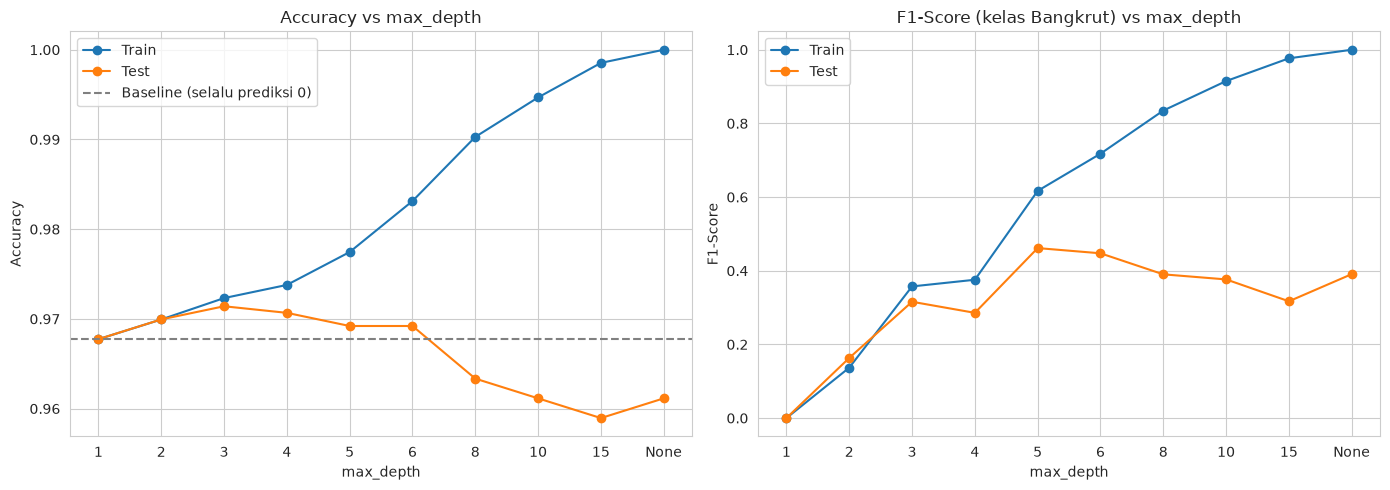

In [26]:
x_labels = depth_results.index.astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x_labels, depth_results['Train Accuracy'], marker='o', label='Train')
axes[0].plot(x_labels, depth_results['Test Accuracy'], marker='o', label='Test')
axes[0].axhline(1 - y_test.mean(), linestyle='--', color='gray', label='Baseline (selalu prediksi 0)')
axes[0].set_title('Accuracy vs max_depth')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(x_labels, depth_results['Train F1'], marker='o', label='Train')
axes[1].plot(x_labels, depth_results['Test F1'], marker='o', label='Test')
axes[1].set_title('F1-Score (kelas Bangkrut) vs max_depth')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('F1-Score')
axes[1].legend()

plt.tight_layout()
plt.show()

Eksperimen max_depth menggunakan kriteria Gini karena memberikan F1-score lebih tinggi dibanding Entropy pada percobaan sebelumnya. Selain accuracy (sesuai instruksi), F1-score kelas bangkrut juga diplot karena accuracy pada data seimbang 97:3 kurang informatif, terbukti pada `max_depth=1` akurasi test sudah 96,77%, persis sama dengan baseline "selalu prediksi tidak bangkrut" dan F1 = 0 (model tidak memprediksi satu pun perusahaan bangkrut).

Pola overfitting terlihat jelas pada grafik: **train accuracy terus naik** dari 96,77% (depth 1) hingga 100% (depth None), sedangkan **test accuracy mencapai puncak pada `max_depth=3`** (97,14%) lalu terus menurun hingga 95,89% pada depth 15. Pola yang sama lebih jelas terlihat pada F1: train F1 naik dari 0 ke 1,0, sedangkan test F1 mencapai puncak di **`max_depth=5` (0,4615)** lalu menurun ke 0,31–0,39 untuk depth ≥ 8. Gap antara train dan test F1 melebar drastis mulai depth 6 (0,72 vs 0,45) hingga depth None (1,00 vs 0,39). Oleh karena itu, `max_depth=5` dipilih sebagai model terbaik karena memberikan F1 test tertinggi dan akurasi test yang masih lebih tinggi dari model tanpa batas.

# 4. Evaluasi Model

In [27]:
best_depth = 5  # dipilih dari eksperimen max_depth di atas
dt_best = depth_models[best_depth]
best_predictions = dt_best.predict(X_test)

models = {
    'DT Gini': gini_predictions,
    'DT Entropy': entropy_predictions,
    f'DT {best_criterion.title()} (max_depth={best_depth})': best_predictions,
}

scores = pd.DataFrame({
    'Accuracy': [accuracy_score(y_test, p) for p in models.values()],
    'Precision': [precision_score(y_test, p) for p in models.values()],
    'Recall': [recall_score(y_test, p) for p in models.values()],
    'F1 Score': [f1_score(y_test, p) for p in models.values()],
}, index=list(models.keys()))

scores

,Accuracy,Precision,Recall,F1 Score
DT Gini,0.961144,0.395349,0.386364,0.390805
DT Entropy,0.958944,0.357143,0.340909,0.348837
DT Gini (max_depth=5),0.969208,0.529412,0.409091,0.461538


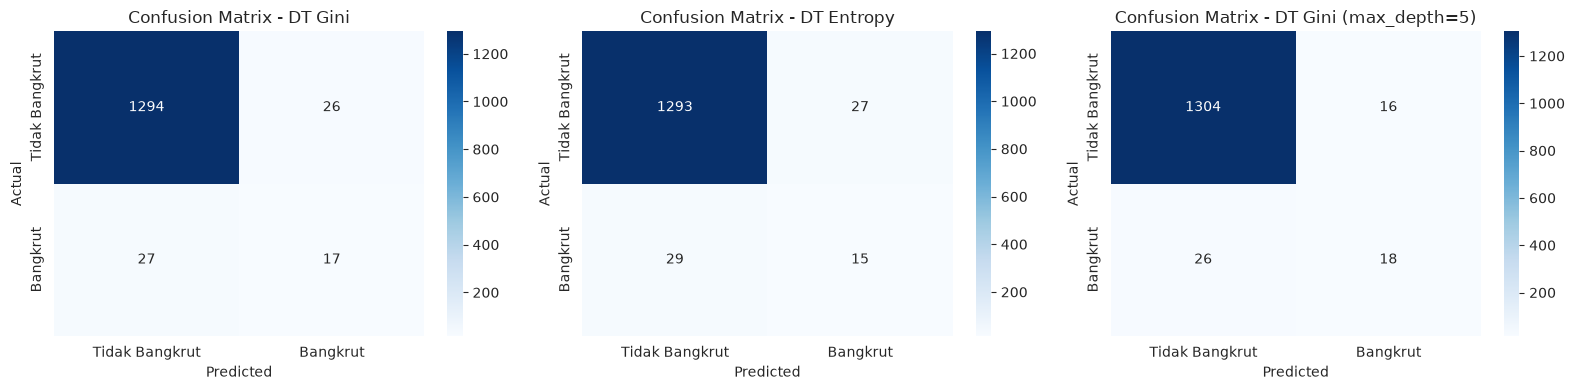

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Tidak Bangkrut', 'Bangkrut'],
                yticklabels=['Tidak Bangkrut', 'Bangkrut'])
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [29]:
for name, pred in models.items():
    print(f'=== {name} ===')
    print(classification_report(y_test, pred, digits=4))

=== DT Gini ===
              precision    recall  f1-score   support

           0     0.9796    0.9803    0.9799      1320
           1     0.3953    0.3864    0.3908        44

    accuracy                         0.9611      1364
   macro avg     0.6875    0.6833    0.6854      1364
weighted avg     0.9607    0.9611    0.9609      1364

=== DT Entropy ===
              precision    recall  f1-score   support

           0     0.9781    0.9795    0.9788      1320
           1     0.3571    0.3409    0.3488        44

    accuracy                         0.9589      1364
   macro avg     0.6676    0.6602    0.6638      1364
weighted avg     0.9580    0.9589    0.9585      1364

=== DT Gini (max_depth=5) ===
              precision    recall  f1-score   support

           0     0.9805    0.9879    0.9842      1320
           1     0.5294    0.4091    0.4615        44

    accuracy                         0.9692      1364
   macro avg     0.7549    0.6985    0.7228      1364
weighted 

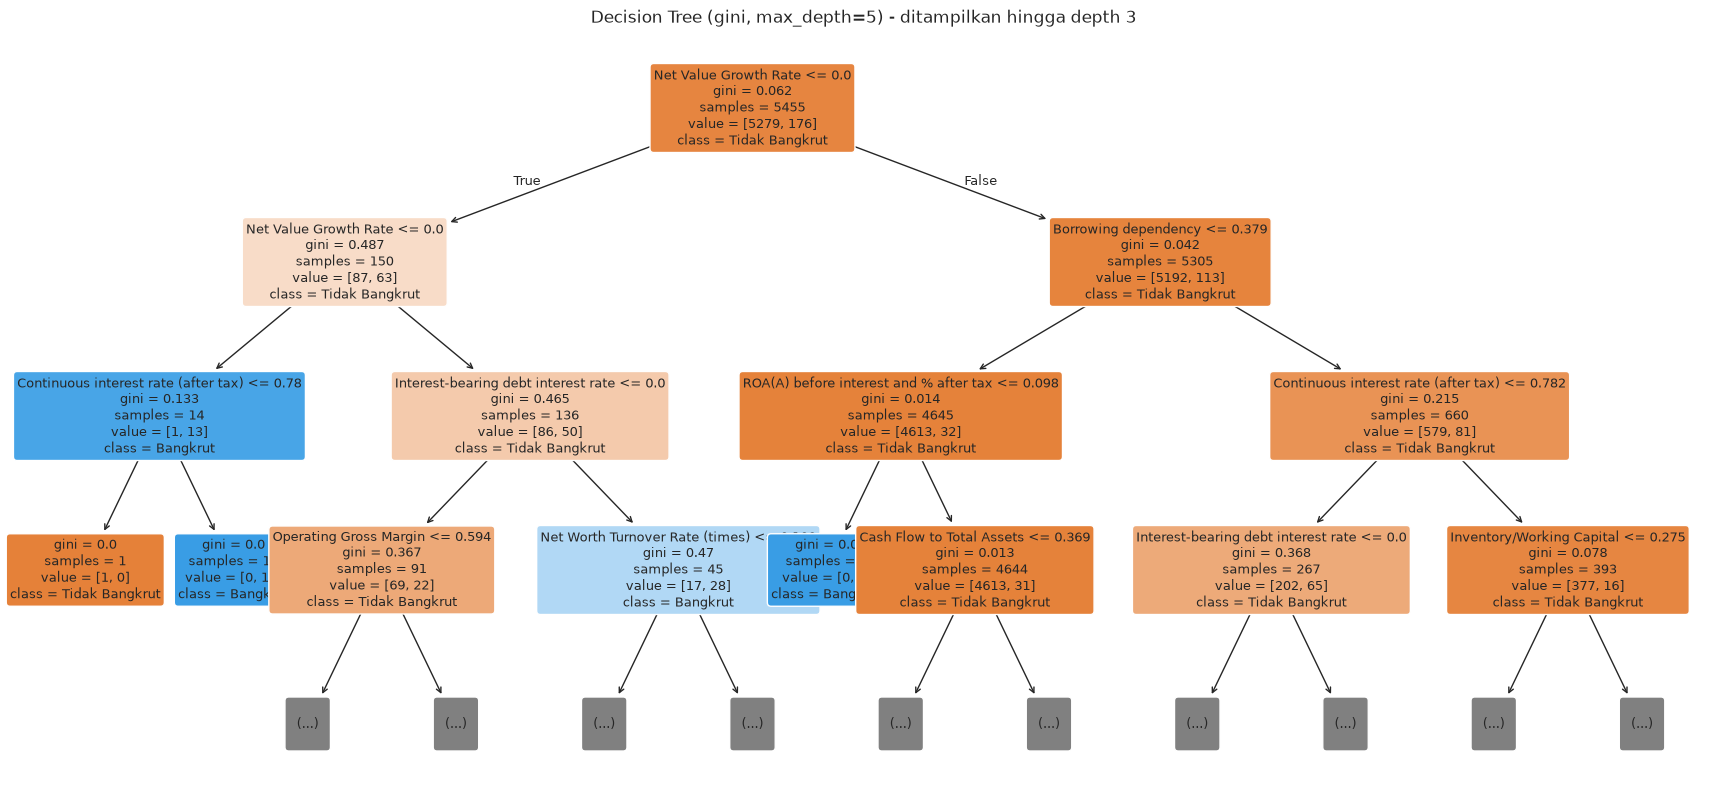

In [30]:
plt.figure(figsize=(22, 10))
plot_tree(dt_best, max_depth=3, feature_names=X.columns, class_names=['Tidak Bangkrut', 'Bangkrut'],
          filled=True, rounded=True, fontsize=9, proportion=False)
plt.title(f'Decision Tree ({best_criterion}, max_depth={best_depth}) - ditampilkan hingga depth 3')
plt.show()

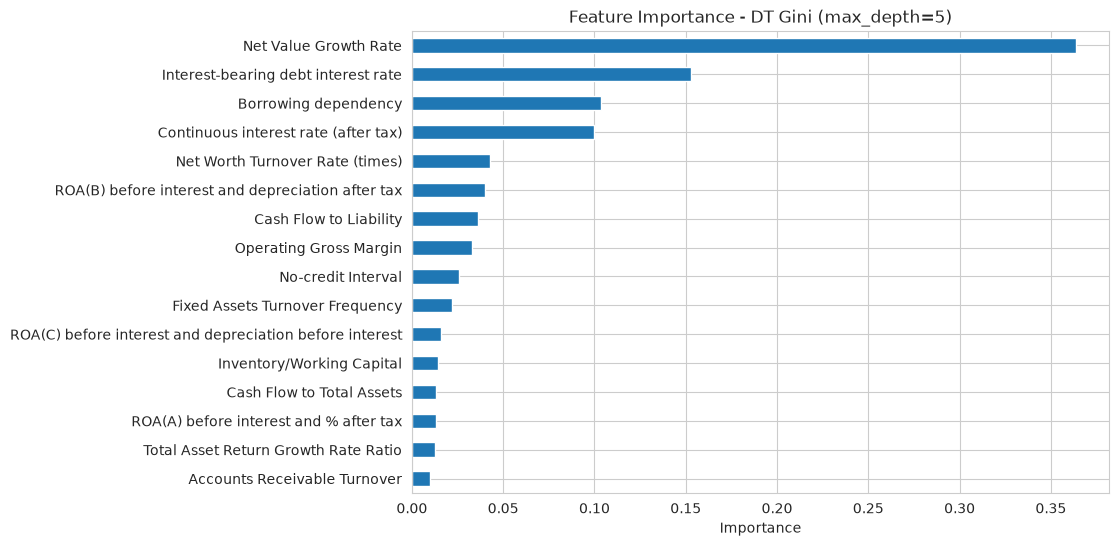

Net Value Growth Rate                                      0.363853
Interest-bearing debt interest rate                        0.153040
Borrowing dependency                                       0.103798
Continuous interest rate (after tax)                       0.099898
Net Worth Turnover Rate (times)                            0.042959
ROA(B) before interest and depreciation after tax          0.040151
Cash Flow to Liability                                     0.036425
Operating Gross Margin                                     0.033092
No-credit Interval                                         0.025702
Fixed Assets Turnover Frequency                            0.022097
ROA(C) before interest and depreciation before interest    0.015718
Inventory/Working Capital                                  0.014191
Cash Flow to Total Assets                                  0.013210
ROA(A) before interest and % after tax                     0.013205
Total Asset Return Growth Rate Ratio            

In [31]:
importances = pd.Series(dt_best.feature_importances_, index=X.columns).sort_values(ascending=False)
top_importances = importances[importances > 0]

plt.figure(figsize=(9, 6))
top_importances.sort_values().plot.barh()
plt.title(f'Feature Importance - DT {best_criterion.title()} (max_depth={best_depth})')
plt.xlabel('Importance')
plt.show()

top_importances

Feature importance model terbaik didominasi oleh `Net Value Growth Rate` (≈ 0,36), diikuti `Interest-bearing debt interest rate` (≈ 0,15), `Borrowing dependency` (≈ 0,10), dan `Continuous interest rate (after tax)` (≈ 0,10). Hanya 16 dari 94 fitur yang digunakan (importance > 0), yang wajar karena tree dengan depth 5 hanya memiliki maksimal 31 split dan banyak fitur saling redundan.

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa Decision Tree dengan kriteria Gini vs Entropy. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (max_depth). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Fitur apa yang paling berpengaruh terhadap prediksi model, berdasarkan feature importance?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

**Perbandingan Gini vs Entropy (tanpa batas kedalaman):**

| Model | Accuracy | Precision | Recall | F1 Score |
|---|---|---|---|---|
| DT Gini | 0.9611 | 0.3953 | 0.3864 | 0.3908 |
| DT Entropy | 0.9589 | 0.3571 | 0.3409 | 0.3488 |
| DT Gini (max_depth=5) | 0.9692 | 0.5294 | 0.4091 | 0.4615 |

Model Gini sedikit unggul dari Entropy di semua metrik, namun perbedaannya **tidak signifikan**. Pada confusion matrix, Gini mendeteksi 17 dari 44 perusahaan bangkrut, sedangkan Entropy mendeteksi 15, selisih hanya 2 sampel dari test set berisi 44 kelas positif, sehingga perbedaan ini bisa saja berubah jika `random_state` atau pembagian data diganti. Hal ini wajar karena secara matematis Gini Impurity dan Entropy memiliki bentuk kurva yang sangat mirip (keduanya maksimum saat distribusi kelas 50:50 dan minimum saat node murni), sehingga keduanya cenderung memilih split yang sama atau serupa. Perbedaan utamanya ada pada struktur tree: Entropy menghasilkan tree yang sedikit lebih kecil (depth 18, 101 leaf) dibanding Gini (depth 20, 124 leaf), namun tidak berdampak besar pada performa. Masalah yang jauh lebih dominan daripada pemilihan kriteria justru adalah **overfitting** dan **ketidakseimbangan kelas**.

**Eksperimen regularisasi (max_depth):**

Gejala overfitting mulai muncul pada **`max_depth` ≈ 5–6**. Ciri-cirinya terlihat dari grafik: akurasi dan F1 train terus naik menuju 100%/1,0, sementara akurasi test sudah mencapai puncak di depth 3 (97,14%) dan F1 test di depth 5 (0,4615), lalu keduanya turun. Pada depth None, model mencapai akurasi train 100% (menghafal seluruh data training) namun F1 test hanya 0,39. Dengan membatasi `max_depth=5`, seluruh metrik test justru membaik dibanding tree tanpa batas: accuracy naik dari 96,11% ke 96,92%, precision dari 0,40 ke 0,53, dan F1 dari 0,39 ke 0,46. Ini membuktikan bahwa regularisasi tidak hanya membuat model lebih sederhana dan mudah diinterpretasi, tetapi juga meningkatkan kemampuan generalisasi.

Perlu dicatat bahwa jika hanya melihat accuracy, hampir semua model terlihat "bagus" (95,9%–97,1%), padahal baseline tanpa model pun sudah 96,77%. Recall kelas bangkrut pada model terbaik masih hanya 0,41 (18 dari 44 perusahaan bangkrut terdeteksi, 26 terlewat), sehingga model masih jauh dari ideal untuk kasus nyata di mana melewatkan perusahaan yang akan bangkrut (false negative) biasanya lebih merugikan.

**Eksperimen preprocessing tambahan:**

Reduksi dimensi dengan TruncatedSVD dan PCA secara konsisten menurunkan F1 (CV F1 terbaik 0,280 vs 0,293 tanpa reduksi, dan hanya 0,042 untuk SVD tanpa transformasi), karena split Decision Tree bekerja per fitur dan komponen hasil reduksi mengaburkan threshold yang bermakna. Teknik reduksi dimensi lebih cocok untuk model berbasis jarak atau linear (seperti KNN atau Logistic Regression) dibanding model berbasis tree. Mengompres hanya kelompok fitur redundan dengan GroupSVD mempertahankan performa (CV F1 0,297) karena 1 komponen sudah mewakili 94–100% variansi tiap kelompok, namun tidak meningkatkannya. Membuang fitur redundan memberikan sedikit peningkatan (CV F1 0,331), namun masih dalam rentang variasi antar fold.

**Feature importance:**

Fitur paling berpengaruh adalah `Net Value Growth Rate` (≈ 0,36) yang juga menjadi root split pada tree. Split ini menarik karena `Net Value Growth Rate` hampir tidak berkorelasi linear dengan target, namun tree menemukan bahwa perusahaan dengan pertumbuhan nilai bersih yang sangat rendah (≈ 0) bersamaan dengan `Continuous interest rate` tinggi hampir seluruhnya bangkrut (13 dari 13 sampel pada leaf tersebut). Ini menunjukkan keunggulan Decision Tree dalam menangkap interaksi dan pola non-linear yang tidak terlihat dari korelasi. Fitur berikutnya, `Interest-bearing debt interest rate` dan `Borrowing dependency`, berkaitan dengan beban utang, konsisten dengan temuan EDA bahwa leverage tinggi berhubungan dengan kebangkrutan. Fitur profitabilitas (ROA A/B/C) juga muncul, namun importance-nya terbagi di antara ketiganya karena sifatnya yang redundan (r > 0,96).

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba pruning dengan ccp_alpha, membandingkan dengan model lain, atau mencoba variasi hyperparameter lain seperti min_samples_leaf), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

**Kesimpulan:**
Pada tugas klasifikasi kebangkrutan perusahaan menggunakan Taiwanese Bankruptcy Dataset, **kriteria Gini dan Entropy memberikan hasil yang hampir sama** (F1 0,3908 vs 0,3488, selisih hanya 2 sampel positif yang terdeteksi), sehingga pemilihan kriteria split tidak berpengaruh signifikan. Faktor yang jauh lebih berpengaruh adalah **regularisasi `max_depth`**: tree tanpa batas mengalami overfitting berat (akurasi train 100%), sedangkan tree dengan `max_depth=5` memberikan hasil terbaik (accuracy 96,92%, precision 0,5294, recall 0,4091, F1 0,4615) sekaligus lebih mudah diinterpretasi. Fitur yang paling berpengaruh adalah `Net Value Growth Rate`, diikuti fitur terkait beban utang (`Interest-bearing debt interest rate`, `Borrowing dependency`). Meski demikian, recall kelas bangkrut yang hanya ±41% menunjukkan bahwa ketidakseimbangan kelas (97:3) masih menjadi kendala utama.

Eksperimen preprocessing tambahan juga menunjukkan bahwa **reduksi dimensi dengan TruncatedSVD/PCA tidak cocok untuk Decision Tree** dan justru menurunkan F1, sedangkan membuang fitur redundan memberikan peningkatan kecil yang belum signifikan.

**Saran untuk eksperimen selanjutnya:**
1. **Menangani ketidakseimbangan kelas**, misalnya dengan `class_weight='balanced'`, oversampling (SMOTE) pada train set saja, atau undersampling, untuk meningkatkan recall kelas bangkrut.
2. **Tuning hyperparameter dengan cross-validation** (misalnya `GridSearchCV` dengan `StratifiedKFold` dan scoring F1) pada `max_depth`, `min_samples_leaf`, dan `ccp_alpha` (cost-complexity pruning), karena test set hanya berisi 44 sampel positif sehingga hasil satu kali split rentan terhadap variasi.
3. **Membersihkan fitur**, yaitu membuang fitur redundan (|r| > 0,95) dan menyelidiki nilai anomali berorde 10⁹–10¹⁰, agar feature importance lebih mudah diinterpretasi.
4. **Membandingkan dengan model ensemble** seperti Random Forest atau Gradient Boosting yang umumnya lebih stabil dan lebih tahan overfitting dibanding single Decision Tree.